In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Пути к данным
PATH = 'peper/'
TRAIN_PATH = PATH + 'homography_data.csv'

# Загрузка данных
train_df = pd.read_csv(TRAIN_PATH)
display(train_df.head())

,image_path,h11,h12,h13,h21,h22,h23,h31,h32
0,peper/input_images\1.png,1.550024,0.085322,-76.249814,-0.200061,2.200670,-118.436065,-0.000760,0.001391
1,peper/input_images\1frame_0000.png,1.756865,0.111463,-288.996300,0.079723,2.642253,-698.784706,0.000056,0.000388
2,peper/input_images\1frame_0001.jpg,1.782410,0.115527,-295.913089,0.046910,2.685599,-753.539157,0.000049,0.000381
3,peper/input_images\1frame_0002.jpg,1.702126,0.072652,-254.426312,0.032984,2.484775,-556.237677,0.000002,0.000310
4,peper/input_images\1frame_0003.jpg,1.784545,0.088949,-279.211813,0.046527,2.558977,-646.444046,0.000023,0.000314


In [4]:
# Нормализация параметров гомографии
scaler = StandardScaler()
train_labels = scaler.fit_transform(train_df.iloc[:, 1:].values)  # Нормализуем параметры

In [5]:
# Преобразование данных
train_images = []
train_sizes = []  # Сохраняем исходные размеры изображений
valid_images = []
valid_indices = []

for idx, img_path in enumerate(train_df['image_path']):
    try:
        img = cv2.imread(img_path)
        if img is not None:
            train_images.append(img)
            train_sizes.append(img.shape[:2])  # Сохраняем (height, width)
        else:
            valid_indices.append(idx)  # Запоминаем индексы пропущенных изображений
    except Exception as e:
        print(f"Ошибка при загрузке изображения {img_path}: {e}")

# Удаляем пропущенные изображения из меток
train_labels = np.delete(train_labels, valid_indices, axis=0)

In [6]:
# Разделение данных на обучающую и тестовую выборки
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=101
)

In [7]:
# Преобразования для изображений
t = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),  # Подгоняем все изображения до одного размера
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
# Функция для масштабирования параметров гомографии
def scale_homography(H, original_size, new_size):
  
    #Масштабир параметры гомографии в соответствии с изменением размеров изображения
   
    original_height, original_width = original_size
    new_height, new_width = new_size

    # Коэффициенты масштабирования
    scale_x = new_width / original_width
    scale_y = new_height / original_height

    # Матрица масштабирования
    scale_matrix = np.array([
        [scale_x, 0, 0],
        [0, scale_y, 0],
        [0, 0, 1]
    ])

    # Масштабируем гомографию
    H_scaled = np.dot(scale_matrix, H)
    return H_scaled

In [9]:
# Класс для создания датасета
class CreateDataset(Dataset):
    def __init__(self, X, y, sizes, transform=None):
        self.X = X
        self.y = y
        self.sizes = sizes  
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inp = self.X[idx].astype(np.float32)
        out = self.y[idx].astype(np.float32)
        original_size = self.sizes[idx]  # Исходные размеры изображения

        if self.transform:
            # Применяем преобразования к изображению
            inp = self.transform(inp)

                           # Масштабируем параметры гомографии
            new_size = (256, 256)  # Новые размеры изображения


            H = np.append(out, 1.0).reshape(3, 3)  # Преобразуем вектор в матрицу 3 на 3
            H_scaled = scale_homography(H, original_size, new_size)
            out = H_scaled.flatten()[:8]  # Возвращаем все 8 параметров

        return inp, out

In [10]:
# Создание датасетов и загрузчиков
train_dataset = CreateDataset(train_images, train_labels, train_sizes, transform=t)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)

test_dataset = CreateDataset(test_images, test_labels, train_sizes, transform=t)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=32)

In [11]:
# HomographyNet: предобученный ResNet-18 + полносвязная голова, предсказывающая 8 параметров гомографии
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        self.backbone = models.resnet18(pretrained=True) # Загружаем ResNet-18 с предобученными весами
        self.backbone.fc = nn.Identity()  # Убираем последний слой ResNet В ResNet последний слой — это полносвязный слой (fc), который используется для классификации. Он имеет 1000 выходов (по количеству классов в ImageNet).nn.Identity(): Заменяем последний слой на "пустой" слой, который просто возвращает входные данные без изменений. Это нужно, чтобы использовать ResNet только как энкодер (для извлечения признаков), а не как классификатор.
        self.fc = nn.Sequential(
            nn.Linear(512, 256),#Полносвязный слой, который принимает 512 входных признаков (выход ResNet) и возвращает 256.
            nn.ReLU(),#Функция активации ReLU (Rectified Linear Unit), которая добавляет нелинейность
            nn.Linear(256, 128),#Второй полносвязный слой, который уменьшает размерность до 128.
            nn.ReLU(),#ReLU — это функция активации, которая имеет пороговое значение
            nn.Linear(128, 8)  # Предсказываем 8 значений финальный слой
        )

    def forward(self, x):
        features = self.backbone(x)#Пропускаем входные данные через ResNet (backbone) для извлечения признаков.
        return self.fc(features)#Пропускаем извлеченные признаки через новый полносвязный блок для получения 8 выходных значений.

In [12]:
# Обучение модели
EPOCHS = 30  # Количество эпох
net = HomographyNet()
criterion = nn.SmoothL1Loss()  # Используем Smooth L1 Loss Функция потерь (Loss Function) измеряет, насколько предсказания модели отличаются от истинных значений.(также известная как Huber Loss). Она сочетает в себе преимущества L1 Loss (менее чувствительна к выбросам) и L2 Loss (гладкая вблизи нуля).
optimizer = AdamW(net.parameters(), lr=0.001, weight_decay=1e-5) #Оптимизатор отвечает за обновление параметров модели (весов) в процессе обучения, чтобы минимизировать функцию потерь.В данном случае используется AdamW — улучшенная версия оптимизатора Adam.Параметры AdamW:net.parameters(): Передаем параметры модели (веса), которые нужно оптимизировать.lr=0.001: Learning Rate (скорость обучения). Определяет, насколько сильно обновляются веса на каждом шаге.weight_decay=1e-5: Регуляризация L2 (weight decay). Штрафует большие значения весов, чтобы предотвратить переобучение.
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)  # Learning Rate Scheduler Планировщик скорости обучения (Learning Rate Scheduler) автоматически изменяет learning rate в процессе обучения, чтобы улучшить сходимость модели.уменьшает learning rate в заданные моменты.Параметры StepLR:optimizer: Оптимизатор, для которого будет изменяться learning rate.step_size=10: Через каждые 10 эпох learning rate будет уменьшаться.gamma=0.1: Насколько сильно уменьшать learning rate. В данном случае learning rate умножается на 0.1 (уменьшается в 10 раз)

y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])
y_train shape: torch.Size([32, 8])
y_pred shape: torch.Size([32, 8])


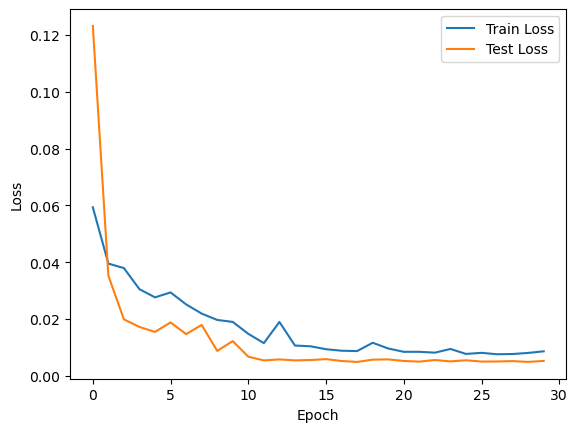

In [13]:

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    for data in train_loader:
        X_train, y_train = data
        optimizer.zero_grad()
        y_pred = net(X_train)

        # Проверка размерностей
        print(f"y_pred shape: {y_pred.shape}")  # Должно быть (batch_size, 8)
        print(f"y_train shape: {y_train.shape}")  # Должно быть (batch_size, 8)

        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        running_loss += train_loss.item()
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()

    # Тестирование на валидационной выборке
    net.eval()
    test_loss = 0.0
    with torch.no_grad():
        for data in test_loader:
            X_test, y_test = data
            output = net(X_test)
            test_loss += criterion(output, y_test).item()
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch: {epoch + 1}, Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

# Визуализация потерь
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [1]:
# Функция для обработки всех изображений из папки
def process_folder(input_folder, output_folder, model, scaler):

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    #  список 
    image_files = [f for f in os.listdir(input_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    
    for image_file in image_files:
        input_path = os.path.join(input_folder, image_file)
        output_path = os.path.join(output_folder, f"aligned_{image_file}")

        
        try:
            # Преобразования для изображения
            transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((256, 256)),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])

            # Загрузка и предобработка изображения
            image = cv2.imread(input_path)
            if image is None:
                print(f"Ошибка: Не удалось загрузить изображение {input_path}.")
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_tensor = transform(image_rgb).unsqueeze(0)  # Добавляем batch dimension

            # Предсказываем параметры гомографии
            with torch.no_grad():
                predicted_params = model(image_tensor)

            # Обратная нормализация параметров
            predicted_params = scaler.inverse_transform(predicted_params.numpy())

            # Преобразуем параметры в матрицу гомографии
            M = np.append(predicted_params.flatten(), 1.0).reshape(3, 3)

            # Выравниваем изображение
            height, width = image.shape[:2]
            aligned_image = cv2.warpPerspective(image, M, (width, height))

         
            cv2.imwrite(output_path, aligned_image)
            print(f"Выровненное изображение сохранено как {output_path}.")

          
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            ax[0].set_title("Исходное изображение")
            ax[0].axis('off')

            ax[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
            ax[1].set_title("Выровненное изображение")
            ax[1].axis('off')

            plt.show()

        except Exception as e:
            print(f"Ошибка при обработке изображения {input_path}: {e}")


input_folder = "peper/extracted_frames"  
output_folder = "peper/testing"   


process_folder(input_folder, output_folder, net, scaler)

NameError: name 'net' is not defined